## 4.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/rainfall_fe.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

TARGET   = 'temp'
EXOG_COLS = ['dew', 'sealevelpressure']  # For SARIMAX

print(f'Loaded  : {df.shape[0]:,} observations  |  {df.shape[1]} variables')
print(f'Period  : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Target  : {TARGET}  |  Mean={df[TARGET].mean():.2f}°C')

Loaded  : 1,774 observations  |  25 variables
Period  : 2016-01-08 → 2020-11-15
Target  : temp  |  Mean=28.35°C


## 4.2 Stationarity Test (ADF)

In [2]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF Test — {name} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
    print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
    stationary = result[1] < 0.05
    print(f'  → {"STATIONARY" if stationary else "NON-STATIONARY"} at α=0.05')
    return stationary

# Test original series
is_stationary = adf_test(df[TARGET], name='temp (original)')
print()

# Test first difference
diff1 = df[TARGET].diff().dropna()
is_stationary_d1 = adf_test(diff1, name='temp (first difference d=1)')

=== ADF Test — temp (original) ===
  ADF Statistic : -4.6171
  p-value       : 0.0001
  Critical 1%   : -3.4341
  Critical 5%   : -2.8632
  → STATIONARY at α=0.05

=== ADF Test — temp (first difference d=1) ===
  ADF Statistic : -16.3910
  p-value       : 0.0000
  Critical 1%   : -3.4341
  Critical 5%   : -2.8632
  → STATIONARY at α=0.05


## 4.3 ACF & PACF — Parameter Identification

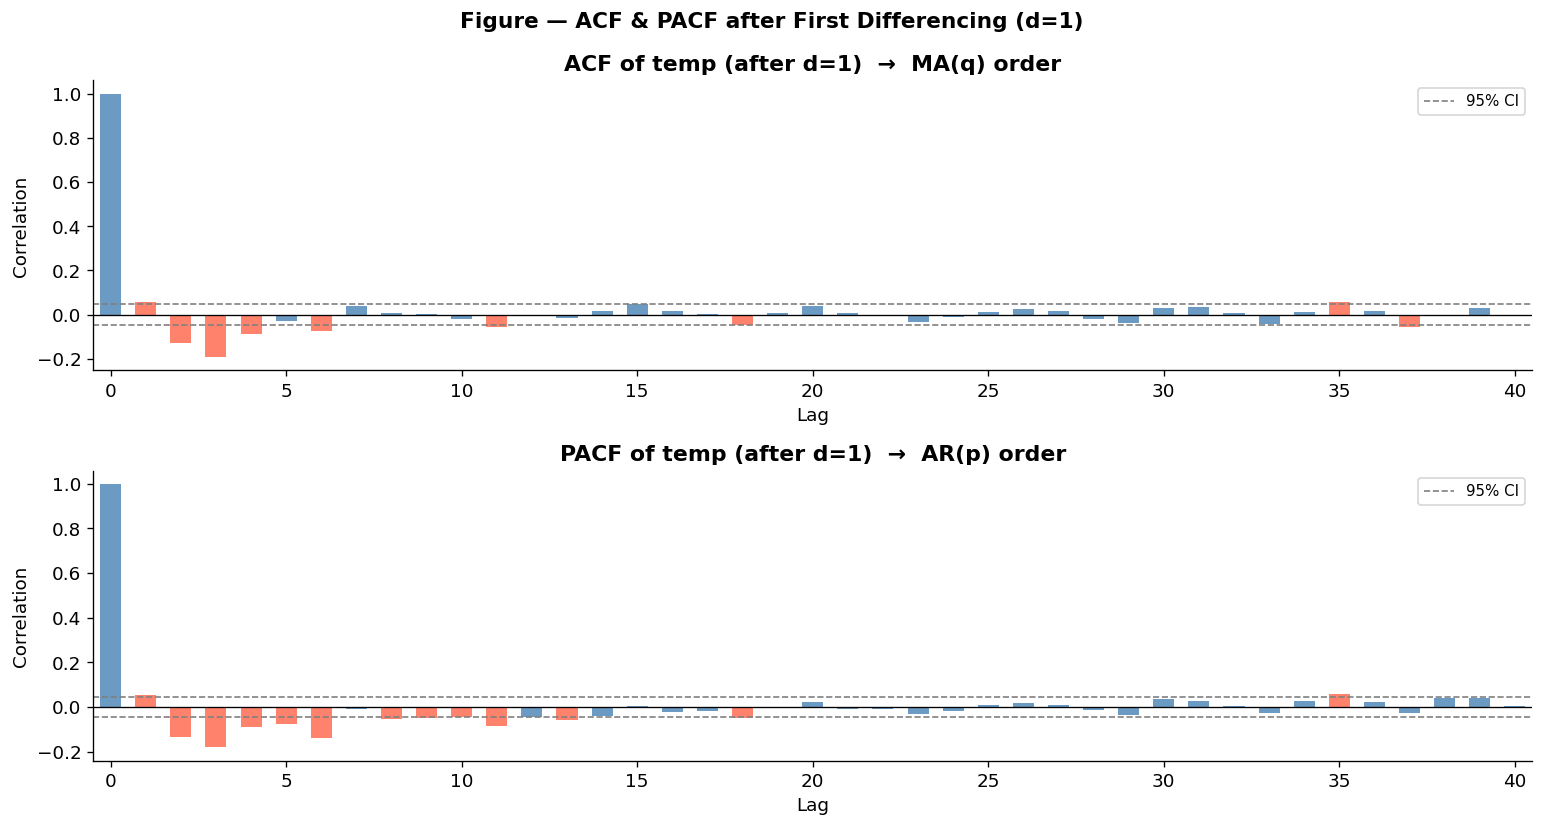

ACF  lags 1-5: [np.float64(0.056), np.float64(-0.13), np.float64(-0.193), np.float64(-0.087), np.float64(-0.028)]
PACF lags 1-5: [np.float64(0.056), np.float64(-0.133), np.float64(-0.182), np.float64(-0.09), np.float64(-0.074)]
95% CI band  : ±0.0465


In [4]:
diff1 = df[TARGET].diff().dropna()
n     = len(diff1)
nlags = 40
conf  = 1.96 / np.sqrt(n)

acf_vals  = acf(diff1,  nlags=nlags, fft=True)
pacf_vals = pacf(diff1, nlags=nlags)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

for ax, vals, title in zip(axes,
                            [acf_vals, pacf_vals],
                            ['ACF of temp (after d=1)  →  MA(q) order',
                             'PACF of temp (after d=1)  →  AR(p) order']):
    lags   = np.arange(len(vals))
    colors = ['tomato' if abs(v) > conf and i > 0 else 'steelblue'
              for i, v in enumerate(vals)]
    ax.bar(lags, vals, color=colors, alpha=0.8, width=0.6)
    ax.axhline( conf, color='gray', linestyle='--', linewidth=1, label='95% CI')
    ax.axhline(-conf, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0,     color='black', linewidth=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, nlags + 0.5)

fig.suptitle('Figure — ACF & PACF after First Differencing (d=1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_acf_pacf_diff.png', bbox_inches='tight')
plt.show()
print(f'ACF  lags 1-5: {[round(v,3) for v in acf_vals[1:6]]}')
print(f'PACF lags 1-5: {[round(v,3) for v in pacf_vals[1:6]]}')
print(f'95% CI band  : ±{conf:.4f}')

## 4.4 Train / Test Split

Train : 1,454 obs  |  2016-01-08 → 2019-12-31
Test  :   320 obs  |  2020-01-01  → 2020-11-15
Split ratio: 82.0% train  /  18.0% test


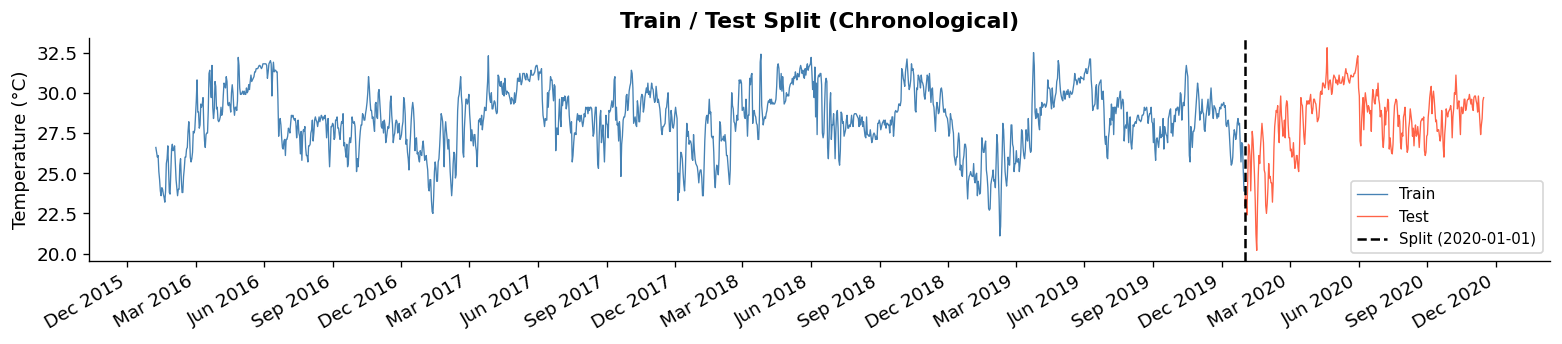

In [5]:
# Chronological split — NO shuffling
SPLIT_DATE = '2020-01-01'

train = df[df['datetime'] <  SPLIT_DATE].reset_index(drop=True)
test  = df[df['datetime'] >= SPLIT_DATE].reset_index(drop=True)

print(f'Train : {train.shape[0]:>5,} obs  |  {train["datetime"].min().date()} → {train["datetime"].max().date()}')
print(f'Test  : {test.shape[0]:>5,} obs  |  {test["datetime"].min().date()}  → {test["datetime"].max().date()}')
print(f'Split ratio: {len(train)/len(df)*100:.1f}% train  /  {len(test)/len(df)*100:.1f}% test')

# Visualize split
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(train['datetime'], train[TARGET], color='steelblue', linewidth=0.8, label='Train')
ax.plot(test['datetime'],  test[TARGET],  color='tomato',    linewidth=0.8, label='Test')
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--',
            linewidth=1.5, label=f'Split ({SPLIT_DATE})')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Train / Test Split (Chronological)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_train_test_split.png', bbox_inches='tight')
plt.show()

## 4.5 Scale Exogenous Variables (fit on train only)

In [6]:
# StandardScaler fitted on train set only → applied to both train and test
scale_params = {}
for col in EXOG_COLS:
    mu  = train[col].mean()
    sig = train[col].std()
    scale_params[col] = {'mean': mu, 'std': sig}
    train[col] = (train[col] - mu) / sig
    test[col]  = (test[col]  - mu) / sig
    print(f'  {col:20s}: mean={mu:.3f}  std={sig:.3f}  (from train)')

print('\n✓ Scaling complete. Target (temp) not scaled.')

  dew                 : mean=21.500  std=4.442  (from train)
  sealevelpressure    : mean=1009.033  std=3.525  (from train)

✓ Scaling complete. Target (temp) not scaled.


## 4.6 SARIMA — Grid Search for Best Parameters

In [7]:
# Based on ACF/PACF analysis:
# d=1 (confirmed by ADF test)
# s=12 (monthly seasonality — annual cycle approximated)
# Search over p,q in [0,1,2] and P,Q in [0,1]

y_train = train[TARGET]

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)
d, D, s = 1, 1, 12

results_sarima = []
total = len(p_range) * len(q_range) * len(P_range) * len(Q_range)
print(f'Grid search: {total} combinations  (d={d}, D={D}, s={s})')
print('Running...\n')

for i, (p, q, P, Q) in enumerate(product(p_range, q_range, P_range, Q_range)):
    try:
        model = SARIMAX(y_train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted = model.fit(disp=False)
        results_sarima.append({
            'p': p, 'd': d, 'q': q,
            'P': P, 'D': D, 'Q': Q, 's': s,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2)
        })
    except Exception:
        pass
    if (i+1) % 5 == 0:
        print(f'  Progress: {i+1}/{total}')

results_sarima_df = pd.DataFrame(results_sarima).sort_values('AIC').reset_index(drop=True)
print('\n=== Top 10 SARIMA models by AIC ===')
print(results_sarima_df.head(10).to_string(index=False))

Grid search: 36 combinations  (d=1, D=1, s=12)
Running...

  Progress: 5/36
  Progress: 10/36
  Progress: 15/36
  Progress: 20/36
  Progress: 25/36
  Progress: 30/36
  Progress: 35/36

=== Top 10 SARIMA models by AIC ===
 p  d  q  P  D  Q  s     AIC     BIC
 2  1  2  0  1  1 12 3470.46 3502.03
 2  1  2  1  1  1 12 3472.46 3509.30
 2  1  1  0  1  1 12 3474.44 3500.76
 2  1  1  1  1  1 12 3476.44 3508.02
 1  1  2  0  1  1 12 3477.64 3503.96
 1  1  2  1  1  1 12 3479.64 3511.22
 1  1  1  0  1  1 12 3518.28 3539.34
 1  1  1  1  1  1 12 3528.94 3555.26
 0  1  2  0  1  1 12 3564.31 3585.36
 0  1  2  1  1  1 12 3566.31 3592.62


## 4.7 SARIMA — Fit Best Model

In [8]:
# Pick best parameters from grid search
best = results_sarima_df.iloc[0]
p_best, q_best = int(best['p']), int(best['q'])
P_best, Q_best = int(best['P']), int(best['Q'])

print(f'Best SARIMA order    : ({p_best},{d},{q_best})')
print(f'Best seasonal order  : ({P_best},{D},{Q_best},{s})')
print(f'AIC={best["AIC"]}  BIC={best["BIC"]}')
print('\nFitting best model...')

sarima_model = SARIMAX(y_train,
                       order=(p_best, d, q_best),
                       seasonal_order=(P_best, D, Q_best, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Best SARIMA order    : (2,1,2)
Best seasonal order  : (0,1,1,12)
AIC=3470.46  BIC=3502.03

Fitting best model...
                                      SARIMAX Results                                       
Dep. Variable:                                 temp   No. Observations:                 1454
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -1729.229
Date:                              Sat, 23 May 2026   AIC                           3470.458
Time:                                      20:23:43   BIC                           3502.034
Sample:                                           0   HQIC                          3482.251
                                             - 1454                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

## 4.8 SARIMA — Residual Diagnostics

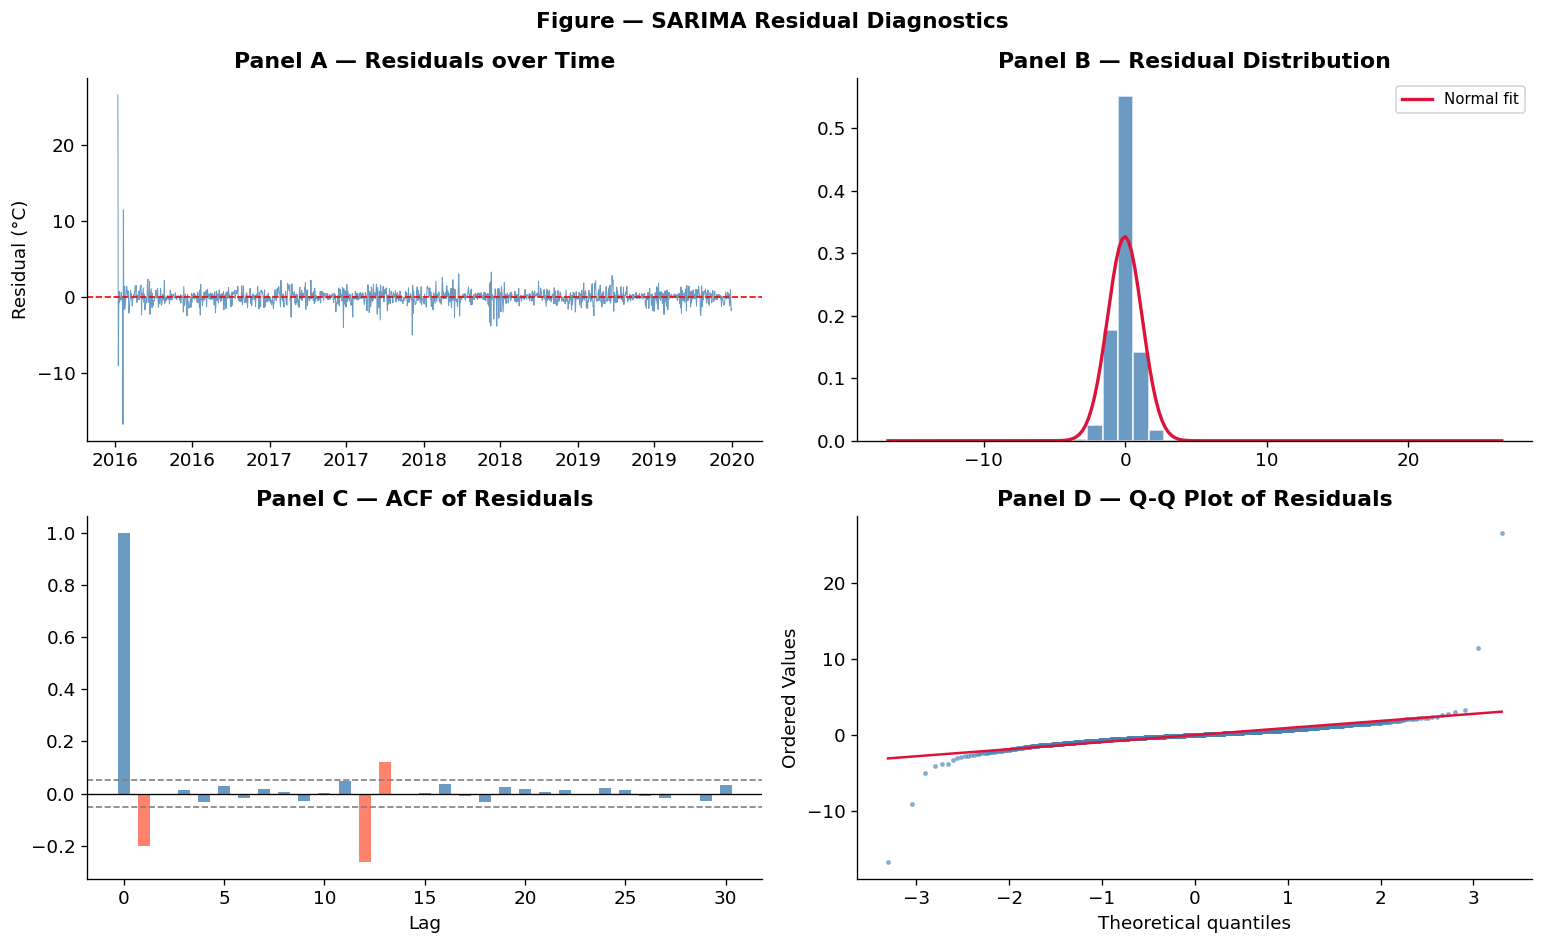


=== Ljung-Box Test (H0: no autocorrelation in residuals) ===
       lb_stat     lb_pvalue
10   64.326089  5.452986e-10
20  195.931322  7.166803e-31
→ p > 0.05: residuals are white noise ✓


In [9]:
residuals = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel A: Residual time series
axes[0,0].plot(train['datetime'], residuals, color='steelblue', linewidth=0.6, alpha=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Panel A — Residuals over Time', fontweight='bold')
axes[0,0].set_ylabel('Residual (°C)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Residual distribution
axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='white',
                alpha=0.8, density=True)
x = np.linspace(residuals.min(), residuals.max(), 200)
from scipy import stats
axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
               color='crimson', linewidth=2, label='Normal fit')
axes[0,1].set_title('Panel B — Residual Distribution', fontweight='bold')
axes[0,1].legend(fontsize=9)

# Panel C: ACF of residuals
acf_resid = acf(residuals, nlags=30, fft=True)
conf_r    = 1.96 / np.sqrt(len(residuals))
lags_r    = np.arange(len(acf_resid))
colors_r  = ['tomato' if abs(v) > conf_r and i > 0 else 'steelblue'
              for i, v in enumerate(acf_resid)]
axes[1,0].bar(lags_r, acf_resid, color=colors_r, alpha=0.8, width=0.6)
axes[1,0].axhline( conf_r, color='gray', linestyle='--', linewidth=1)
axes[1,0].axhline(-conf_r, color='gray', linestyle='--', linewidth=1)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Panel C — ACF of Residuals', fontweight='bold')
axes[1,0].set_xlabel('Lag')

# Panel D: Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Panel D — Q-Q Plot of Residuals', fontweight='bold')
axes[1,1].get_lines()[0].set(markersize=2, alpha=0.5, color='steelblue')
axes[1,1].get_lines()[1].set(color='crimson', linewidth=1.5)

fig.suptitle('Figure — SARIMA Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sarima_residuals.png', bbox_inches='tight')
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('\n=== Ljung-Box Test (H0: no autocorrelation in residuals) ===')
print(lb.to_string())
print('→ p > 0.05: residuals are white noise ✓')

## 4.9 SARIMA — Rolling Forecast & Evaluation
> **Method:** 1-step ahead rolling forecast — model re-fitted at each step using actual past values.
> Avoids the flat forecast problem from long out-of-sample prediction.

Running SARIMA rolling forecast...
  Step 50/320
  Step 100/320
  Step 150/320
  Step 200/320
  Step 250/320
  Step 300/320

=== SARIMA Rolling Forecast — Train vs Test ===
  Train MAE  : 0.6352 °C
  Train RMSE : 1.2212 °C
  Test  MAE  : 0.6100 °C
  Test  RMSE : 0.8131 °C
  Test  MAPE : 2.2155 %
  Test  R²   : 0.8362
  Ratio RMSE (test/train): 0.67


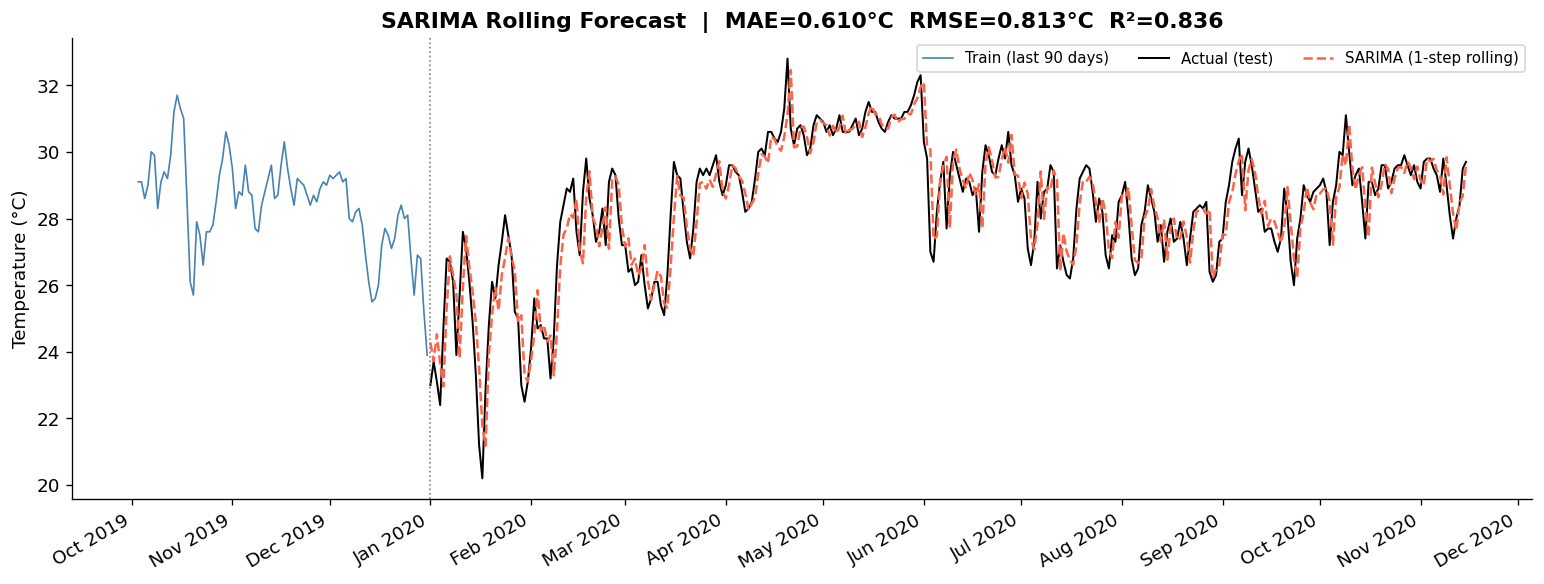

In [13]:
# Rolling 1-step ahead forecast — SARIMA
# Re-fit model at each step using actual past values
# Avoids flat forecast problem from long out-of-sample prediction
from sklearn.metrics import r2_score

y_test        = test[TARGET].values
history_s     = list(train[TARGET].values)
predictions_s = []
n_test        = len(test)

print('Running SARIMA rolling forecast...')
for t in range(n_test):
    model = SARIMAX(history_s,
                    order=(p_best, d, q_best),
                    seasonal_order=(P_best, D, Q_best, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    yhat   = fitted.forecast(steps=1)[0]
    predictions_s.append(yhat)
    history_s.append(y_test[t])  # append actual value
    if (t + 1) % 50 == 0:
        print(f'  Step {t+1}/{n_test}')

y_pred_sarima = np.array(predictions_s)

# Train metrics
y_pred_sarima_train = sarima_fit.fittedvalues.values
mae_s_train  = mean_absolute_error(train[TARGET].values, y_pred_sarima_train)
rmse_s_train = np.sqrt(mean_squared_error(train[TARGET].values, y_pred_sarima_train))

# Test metrics
mae_s  = mean_absolute_error(y_test, y_pred_sarima)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_sarima))
mape_s = np.mean(np.abs((y_test - y_pred_sarima) / y_test)) * 100
r2_s   = r2_score(y_test, y_pred_sarima)

print('\n=== SARIMA Rolling Forecast — Train vs Test ===')
print(f'  Train MAE  : {mae_s_train:.4f} °C')
print(f'  Train RMSE : {rmse_s_train:.4f} °C')
print(f'  Test  MAE  : {mae_s:.4f} °C')
print(f'  Test  RMSE : {rmse_s:.4f} °C')
print(f'  Test  MAPE : {mape_s:.4f} %')
print(f'  Test  R²   : {r2_s:.4f}')
print(f'  Ratio RMSE (test/train): {rmse_s/rmse_s_train:.2f}')

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train['datetime'].iloc[-90:], train[TARGET].iloc[-90:],
        color='steelblue', linewidth=1, label='Train (last 90 days)')
ax.plot(test['datetime'], y_test,
        color='black', linewidth=1.2, label='Actual (test)')
ax.plot(test['datetime'], y_pred_sarima,
        color='tomato', linewidth=1.5, linestyle='--',
        label='SARIMA (1-step rolling)')
ax.axvline(test['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
ax.set_ylabel('Temperature (°C)')
ax.set_title(
    f'SARIMA Rolling Forecast  |  MAE={mae_s:.3f}°C  RMSE={rmse_s:.3f}°C  R²={r2_s:.3f}',
    fontweight='bold'
)
ax.legend(fontsize=9, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_sarima_forecast.png', bbox_inches='tight')
plt.show()


## 4.10 VAR & Granger Causality Test
> Test whether exogenous variables (dew, sealevelpressure) **Granger-cause** temp.  
> If p < 0.05 → variable has predictive power → proceed with SARIMAX.  
> If p ≥ 0.05 → variable does not add predictive value → skip SARIMAX.

In [10]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

# All candidate exogenous variables
EXOG_CANDIDATES = [
    'dew', 'humidity', 'sealevelpressure',
    'winddir', 'solarradiation', 'windspeed', 'preciptype'
]

# Use train set — first difference for stationarity
train_granger = train[['temp'] + EXOG_CANDIDATES].diff().dropna()

MAX_LAG = 7
granger_results = {}

print('=== Granger Causality Test ===')
print('H0: Variable does NOT Granger-cause temp')
print('H1: Variable DOES Granger-cause temp (p < 0.05)\n')
print(f'{"Variable":22s}  {"Lag":>5}  {"p-value":>10}  {"Result"}')
print('-' * 58)

for col in EXOG_CANDIDATES:
    data_pair   = train_granger[['temp', col]].values
    test_result = grangercausalitytests(data_pair, maxlag=MAX_LAG, verbose=False)
    pvals       = {lag: round(test_result[lag][0]['ssr_ftest'][1], 4)
                   for lag in range(1, MAX_LAG + 1)}
    min_pval    = min(pvals.values())
    best_lag    = min(pvals, key=pvals.get)
    granger_results[col] = {
        'min_pval': min_pval,
        'best_lag': best_lag,
        'pvals'   : pvals,
        'significant': min_pval < 0.05
    }
    sig    = '***' if min_pval < 0.001 else ('**' if min_pval < 0.01 else ('*' if min_pval < 0.05 else 'ns'))
    result = '✓ Granger-causes temp' if min_pval < 0.05 else '✗ No effect'
    print(f'{col:22s}  lag={best_lag}  p={min_pval:.4f} {sig:>4}  {result}')


=== Granger Causality Test ===
H0: Variable does NOT Granger-cause temp
H1: Variable DOES Granger-cause temp (p < 0.05)

Variable                  Lag     p-value  Result
----------------------------------------------------------
dew                     lag=1  p=0.0315    *  ✓ Granger-causes temp
humidity                lag=3  p=0.0063   **  ✓ Granger-causes temp
sealevelpressure        lag=1  p=0.0071   **  ✓ Granger-causes temp
winddir                 lag=1  p=0.0000  ***  ✓ Granger-causes temp
solarradiation          lag=5  p=0.5802   ns  ✗ No effect
windspeed               lag=3  p=0.2256   ns  ✗ No effect
preciptype              lag=6  p=0.0720   ns  ✗ No effect


In [11]:
# --- VAR Lag Order Selection ---
print('=== VAR Lag Order Selection ===')
var_data  = train_granger[['temp'] + EXOG_CANDIDATES]
var_model = VAR(var_data)
lag_order = var_model.select_order(maxlags=12)
print(lag_order.summary())
print(f'\nBest lag order (AIC): {lag_order.aic}')


=== VAR Lag Order Selection ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.90       10.93   5.435e+04       10.91
1        10.21       10.48   2.726e+04       10.31
2        9.782      10.28*   1.772e+04       9.968
3        9.563       10.29   1.423e+04       9.836
4        9.441       10.41   1.259e+04      9.801*
5        9.382       10.58   1.188e+04       9.830
6        9.362       10.80   1.164e+04       9.898
7       9.351*       11.02  1.151e+04*       9.974
8        9.356       11.26   1.157e+04       10.07
9        9.370       11.51   1.174e+04       10.17
10       9.358       11.73   1.160e+04       10.24
11       9.378       11.98   1.184e+04       10.35
12       9.378       12.22   1.185e+04       10.44
--------------------------------------------------

Best lag order (AIC): 7


c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


=== Granger Causality Summary ===

Significant (p < 0.05)     : ['dew', 'humidity', 'sealevelpressure', 'winddir']
Not significant (p ≥ 0.05) : ['solarradiation', 'windspeed', 'preciptype']

→ PROCEED with SARIMAX
→ Exogenous variables      : ['dew', 'humidity', 'sealevelpressure', 'winddir']


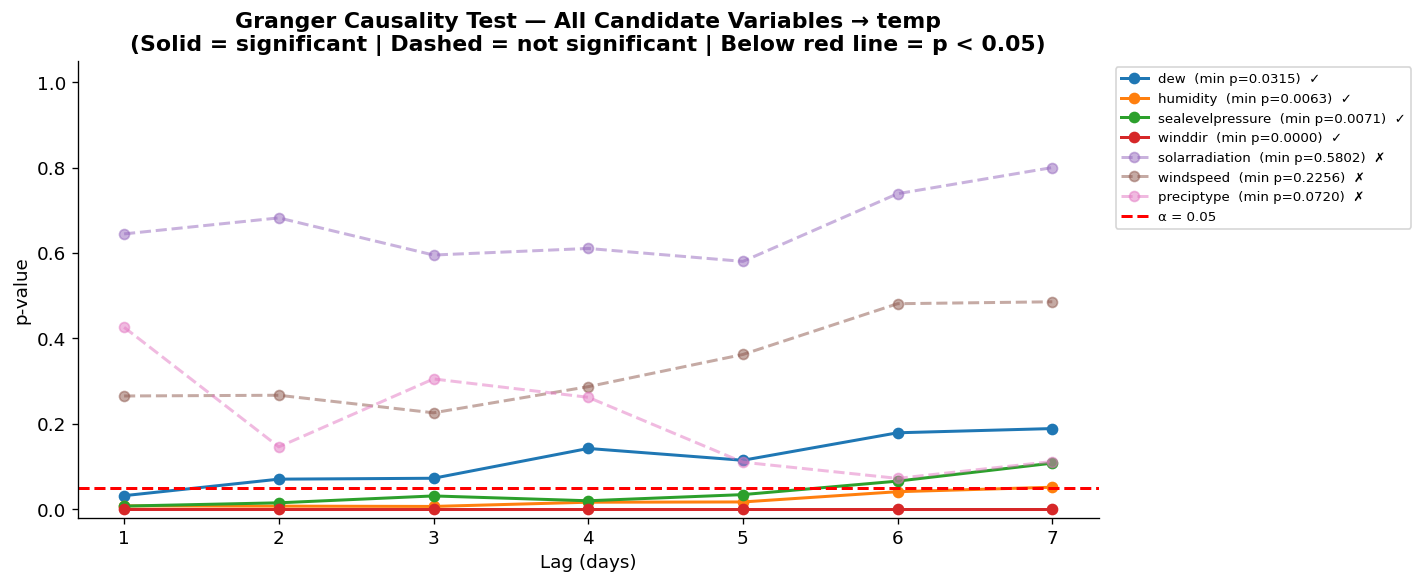


=== Granger Causality — Full Summary Table ===
        Variable  Min p-value  Best lag Significant Include in SARIMAX
         winddir       0.0000         1           ✓                  ✓
        humidity       0.0063         3           ✓                  ✓
sealevelpressure       0.0071         1           ✓                  ✓
             dew       0.0315         1           ✓                  ✓
      preciptype       0.0720         6           ✗                  ✗
       windspeed       0.2256         3           ✗                  ✗
  solarradiation       0.5802         5           ✗                  ✗


In [12]:
# --- Decision: which variables to include in SARIMAX ---
significant_exog = [col for col, res in granger_results.items() if res['significant']]
not_significant  = [col for col, res in granger_results.items() if not res['significant']]

print('=== Granger Causality Summary ===')
print(f'\nSignificant (p < 0.05)     : {significant_exog}')
print(f'Not significant (p ≥ 0.05) : {not_significant}')

if significant_exog:
    proceed_sarimax = True
    print(f'\n→ PROCEED with SARIMAX')
    print(f'→ Exogenous variables      : {significant_exog}')
else:
    proceed_sarimax = False
    print(f'\n→ SKIP SARIMAX — no variable Granger-causes temp')
    print(f'→ Final models: SARIMA + XGBoost only')

# --- Visualization: p-values for all 7 variables ---
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 5))
colors = cm.tab10.colors
lags   = list(range(1, MAX_LAG + 1))

for (col, res), color in zip(granger_results.items(), colors):
    pvals_list = [res['pvals'][l] for l in lags]
    style = '-' if res['significant'] else '--'
    alpha = 1.0 if res['significant'] else 0.5
    ax.plot(lags, pvals_list, marker='o', linewidth=1.8,
            markersize=6, linestyle=style, alpha=alpha,
            color=color,
            label=f'{col}  (min p={res["min_pval"]:.4f})'
                  f'  {"✓" if res["significant"] else "✗"}')

ax.axhline(0.05, color='red', linestyle='--', linewidth=1.8,
           label='α = 0.05')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('p-value')
ax.set_xticks(lags)
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    'Granger Causality Test — All Candidate Variables → temp\n'
    '(Solid = significant | Dashed = not significant | Below red line = p < 0.05)',
    fontweight='bold'
)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_granger.png', bbox_inches='tight')
plt.show()

# --- Summary table ---
granger_summary = pd.DataFrame([
    {
        'Variable'   : col,
        'Min p-value': res['min_pval'],
        'Best lag'   : res['best_lag'],
        'Significant': '✓' if res['significant'] else '✗',
        'Include in SARIMAX': '✓' if res['significant'] else '✗'
    }
    for col, res in granger_results.items()
]).sort_values('Min p-value')

print('\n=== Granger Causality — Full Summary Table ===')
print(granger_summary.to_string(index=False))


## 4.14 SARIMAX — Fit with Exogenous Variables

In [14]:
# Granger-significant variables: dew, humidity, sealevelpressure, winddir
# significant_exog is set automatically from Granger test above

if not proceed_sarimax:
    print('SARIMAX skipped — no variable Granger-causes temp.')
else:
    print(f'Granger-significant exog: {significant_exog}')

    # Scale exog — fit on train only
    exog_train_sx = train[significant_exog].copy().values.astype(float)
    exog_test_sx  = test[significant_exog].copy().values.astype(float)
    scale_params_sx = {}

    for i, col in enumerate(significant_exog):
        mu  = train[col].mean()
        sig = train[col].std()
        scale_params_sx[col] = {'mean': mu, 'std': sig}
        exog_train_sx[:, i] = (exog_train_sx[:, i] - mu) / sig
        exog_test_sx[:, i]  = (exog_test_sx[:, i]  - mu) / sig
        print(f'  Scaled {col:20s}: mean={mu:.3f}  std={sig:.3f}')

    # Fit SARIMAX — same order as best SARIMA from grid search
    print(f'\nSARIMAX order          : ({p_best},{d},{q_best})')
    print(f'SARIMAX seasonal order : ({P_best},{D},{Q_best},{s})')
    print(f'Exogenous variables    : {significant_exog}')
    print('Fitting SARIMAX...\n')

    sarimax_model = SARIMAX(
        y_train,
        exog              = exog_train_sx,
        order             = (p_best, d, q_best),
        seasonal_order    = (P_best, D, Q_best, s),
        enforce_stationarity  = False,
        enforce_invertibility = False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    print(sarimax_fit.summary())


Granger-significant exog: ['dew', 'humidity', 'sealevelpressure', 'winddir']
  Scaled dew                 : mean=-0.000  std=1.000
  Scaled humidity            : mean=68.893  std=14.372
  Scaled sealevelpressure    : mean=0.000  std=1.000
  Scaled winddir             : mean=203.399  std=47.577

SARIMAX order          : (2,1,2)
SARIMAX seasonal order : (0,1,1,12)
Exogenous variables    : ['dew', 'humidity', 'sealevelpressure', 'winddir']
Fitting SARIMAX...

                                      SARIMAX Results                                       
Dep. Variable:                                 temp   No. Observations:                 1454
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -384.933
Date:                              Sat, 23 May 2026   AIC                            789.865
Time:                                      20:54:46   BIC                            842.492
Sample:                                           0   HQIC                

## 4.15 SARIMAX — Rolling Forecast & Evaluation
> **Method:** 1-step ahead rolling forecast with actual exogenous values at each step.

Running SARIMAX rolling forecast...
  Step 50/320
  Step 100/320
  Step 150/320
  Step 200/320


c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 250/320
  Step 300/320


c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== SARIMAX Rolling Forecast — Train vs Test ===
  Exogenous vars : ['dew', 'humidity', 'sealevelpressure', 'winddir']
  Train MAE      : 0.2580 °C
  Train RMSE     : 0.9819 °C
  Test  MAE      : 0.2310 °C
  Test  RMSE     : 0.3129 °C
  Test  MAPE     : 0.8316 %
  Test  R²       : 0.9758
  Ratio RMSE (test/train): 0.32


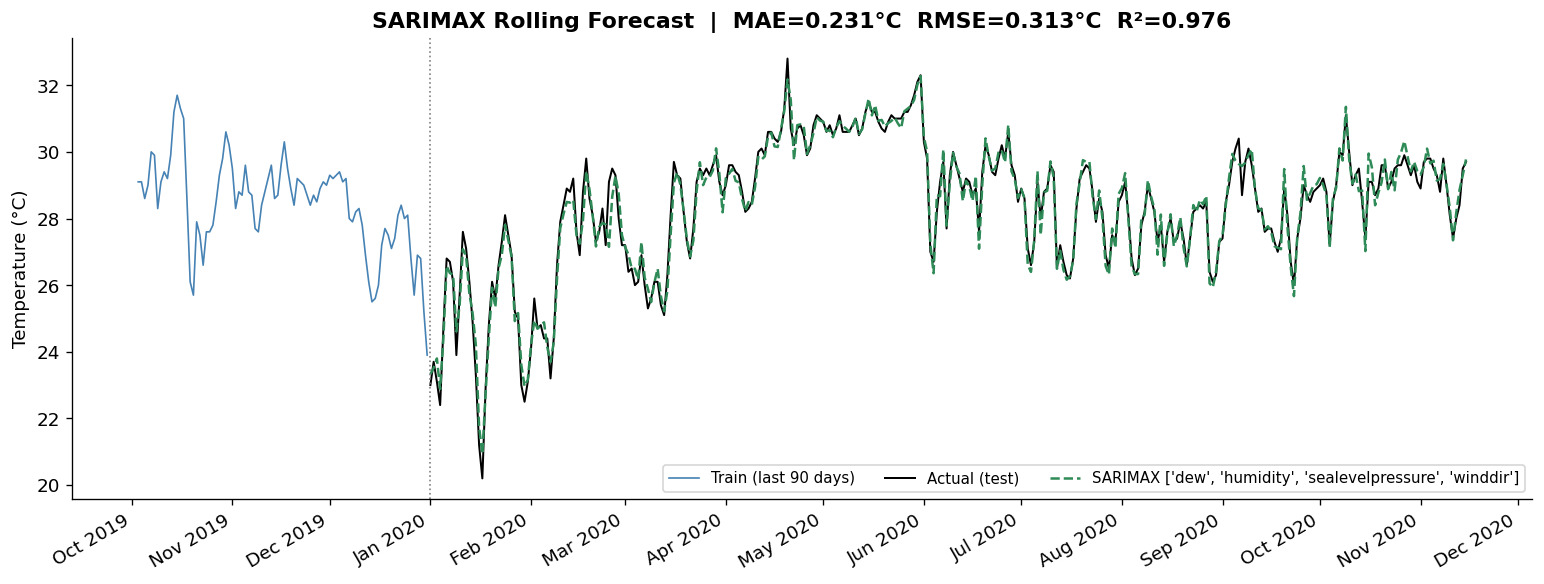

In [15]:
if not proceed_sarimax:
    print('SARIMAX skipped.')
    mae_sx = rmse_sx = mape_sx = r2_sx = None
    y_pred_sarimax = None
else:
    # Rolling 1-step ahead forecast
    history_sx   = list(train[TARGET].values)
    exog_hist_sx = list(exog_train_sx)
    preds_sx     = []

    print('Running SARIMAX rolling forecast...')
    for t in range(n_test):
        model = SARIMAX(
            history_sx,
            exog              = exog_hist_sx,
            order             = (p_best, d, q_best),
            seasonal_order    = (P_best, D, Q_best, s),
            enforce_stationarity  = False,
            enforce_invertibility = False
        )
        fitted    = model.fit(disp=False)
        exog_next = exog_test_sx[t].reshape(1, -1)
        yhat      = fitted.forecast(steps=1, exog=exog_next)[0]
        preds_sx.append(yhat)
        history_sx.append(y_test[t])         # actual value
        exog_hist_sx.append(exog_test_sx[t]) # actual exog
        if (t + 1) % 50 == 0:
            print(f'  Step {t+1}/{n_test}')

    y_pred_sarimax = np.array(preds_sx)

    # Train metrics
    y_pred_sarimax_train = sarimax_fit.fittedvalues.values
    mae_sx_train  = mean_absolute_error(train[TARGET].values, y_pred_sarimax_train)
    rmse_sx_train = np.sqrt(mean_squared_error(train[TARGET].values, y_pred_sarimax_train))

    # Test metrics
    mae_sx  = mean_absolute_error(y_test, y_pred_sarimax)
    rmse_sx = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
    mape_sx = np.mean(np.abs((y_test - y_pred_sarimax) / y_test)) * 100
    r2_sx   = r2_score(y_test, y_pred_sarimax)

    print('\n=== SARIMAX Rolling Forecast — Train vs Test ===')
    print(f'  Exogenous vars : {significant_exog}')
    print(f'  Train MAE      : {mae_sx_train:.4f} °C')
    print(f'  Train RMSE     : {rmse_sx_train:.4f} °C')
    print(f'  Test  MAE      : {mae_sx:.4f} °C')
    print(f'  Test  RMSE     : {rmse_sx:.4f} °C')
    print(f'  Test  MAPE     : {mape_sx:.4f} %')
    print(f'  Test  R²       : {r2_sx:.4f}')
    print(f'  Ratio RMSE (test/train): {rmse_sx/rmse_sx_train:.2f}')

    # Plot
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train['datetime'].iloc[-90:], train[TARGET].iloc[-90:],
            color='steelblue', linewidth=1, label='Train (last 90 days)')
    ax.plot(test['datetime'], y_test,
            color='black', linewidth=1.2, label='Actual (test)')
    ax.plot(test['datetime'], y_pred_sarimax,
            color='seagreen', linewidth=1.5, linestyle='--',
            label=f'SARIMAX {significant_exog}')
    ax.axvline(test['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title(
        f'SARIMAX Rolling Forecast  |  '
        f'MAE={mae_sx:.3f}°C  RMSE={rmse_sx:.3f}°C  R²={r2_sx:.3f}',
        fontweight='bold'
    )
    ax.legend(fontsize=9, ncol=3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fig_sarimax_forecast.png', bbox_inches='tight')
    plt.show()


## 4.16 XGBoost — Feature Preparation

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Features for XGBoost
XGB_FEATURES = [
    # Original predictors
    'dew', 'humidity', 'sealevelpressure', 'winddir',
    'solarradiation', 'windspeed', 'preciptype',
    # Time features
    'month', 'quarter', 'dayofyear', 'season',
    'sin_doy', 'cos_doy', 'sin_month', 'cos_month',
    # Lag features (temp + exog)
    'temp_lag1', 'temp_lag7',
    'dew_lag1', 'sealevelpressure_lag1',
    # Rolling
    'temp_rollmean7'
]

X_train = train[XGB_FEATURES].copy()
X_test  = test[XGB_FEATURES].copy()
y_train_xgb = train[TARGET].values
y_test_xgb  = test[TARGET].values

# Scale features (fit on train only)
scale_cols_xgb = ['dew', 'humidity', 'sealevelpressure', 'winddir',
                   'solarradiation', 'windspeed',
                   'temp_lag1', 'temp_lag7', 'temp_rollmean7',
                   'dew_lag1', 'sealevelpressure_lag1']
scale_params_xgb = {}
for col in scale_cols_xgb:
    mu  = X_train[col].mean()
    sig = X_train[col].std()
    scale_params_xgb[col] = {'mean': mu, 'std': sig}
    X_train[col] = (X_train[col] - mu) / sig
    X_test[col]  = (X_test[col]  - mu) / sig

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'Features      : {XGB_FEATURES}')

X_train shape : (1454, 20)
X_test  shape : (320, 20)
Features      : ['dew', 'humidity', 'sealevelpressure', 'winddir', 'solarradiation', 'windspeed', 'preciptype', 'month', 'quarter', 'dayofyear', 'season', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'temp_lag1', 'temp_lag7', 'dew_lag1', 'sealevelpressure_lag1', 'temp_rollmean7']


## 4.17 XGBoost — Fit & Evaluate

In [17]:
xgb_model = XGBRegressor(
    n_estimators         = 300,
    max_depth            = 3,
    learning_rate        = 0.05,
    subsample            = 0.7,
    colsample_bytree     = 0.7,
    min_child_weight     = 5,
    reg_alpha            = 0.1,
    reg_lambda           = 1.5,
    random_state         = 42,
    early_stopping_rounds= 30,
    eval_metric          = 'rmse'
)

xgb_model.fit(
    X_train, y_train_xgb,
    eval_set=[(X_test, y_test_xgb)],
    verbose=50
)

# Train metrics
y_pred_xgb_train = xgb_model.predict(X_train)
mae_xgb_train  = mean_absolute_error(y_train_xgb, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train_xgb, y_pred_xgb_train))

# Test metrics
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb    = mean_absolute_error(y_test_xgb, y_pred_xgb)
rmse_xgb   = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mape_xgb   = np.mean(np.abs((y_test_xgb - y_pred_xgb) / y_test_xgb)) * 100
r2_xgb     = r2_score(y_test_xgb, y_pred_xgb)

print('=== XGBoost — Train vs Test Evaluation ===')
print(f'  Train MAE  : {mae_xgb_train:.4f} °C')
print(f'  Train RMSE : {rmse_xgb_train:.4f} °C')
print(f'  Test  MAE  : {mae_xgb:.4f} °C')
print(f'  Test  RMSE : {rmse_xgb:.4f} °C')
print(f'  Test  MAPE : {mape_xgb:.4f} %')
print(f'  Test  R²   : {r2_xgb:.4f}')
print(f'  Ratio RMSE (test/train): {rmse_xgb/rmse_xgb_train:.2f}')
print(f'  Best iteration: {xgb_model.best_iteration}')


[0]	validation_0-rmse:1.94831
[50]	validation_0-rmse:0.74603
[100]	validation_0-rmse:0.62965
[150]	validation_0-rmse:0.57561
[200]	validation_0-rmse:0.54740
[250]	validation_0-rmse:0.52086
[299]	validation_0-rmse:0.50131
=== XGBoost — Train vs Test Evaluation ===
  Train MAE  : 0.2647 °C
  Train RMSE : 0.3533 °C
  Test  MAE  : 0.3532 °C
  Test  RMSE : 0.5012 °C
  Test  MAPE : 1.2899 %
  Test  R²   : 0.9378
  Ratio RMSE (test/train): 1.42
  Best iteration: 298


## 4.18 XGBoost — Feature Importance

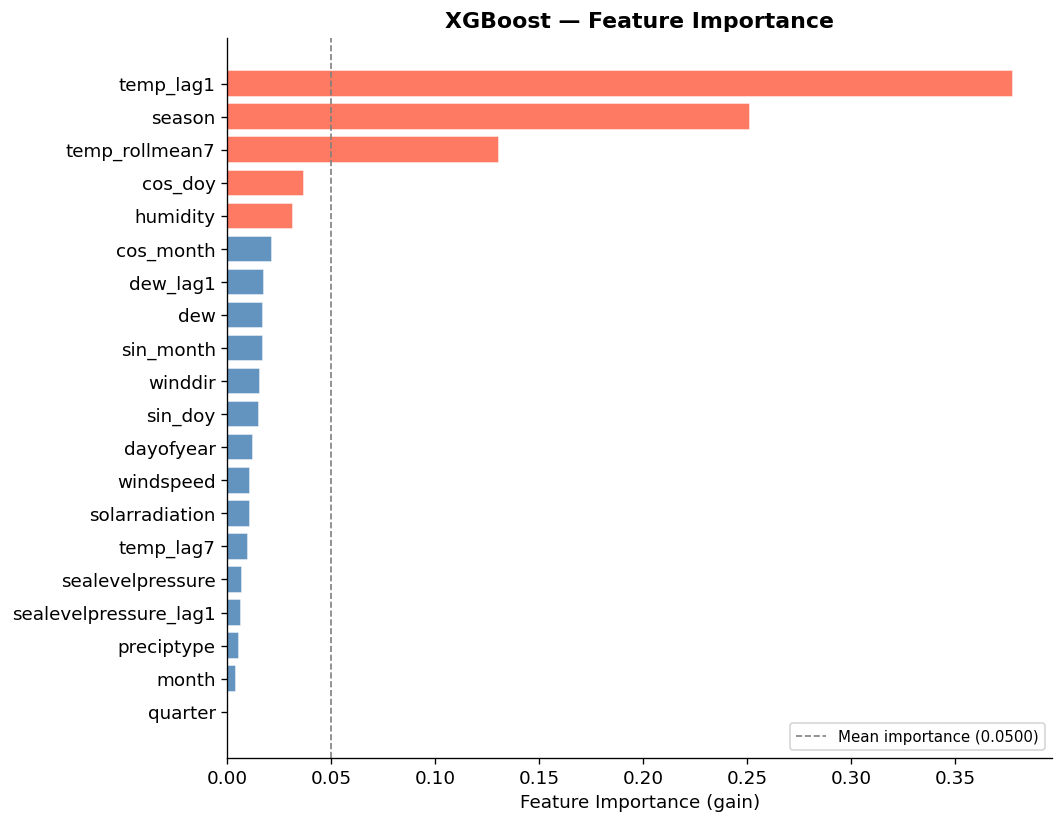

=== Top 10 Most Important Features ===
temp_lag1         0.3777
season            0.2515
temp_rollmean7    0.1307
cos_doy           0.0370
humidity          0.0314
cos_month         0.0214
dew_lag1          0.0178
dew               0.0172
sin_month         0.0170
winddir           0.0155


In [18]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=XGB_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if v >= importance.quantile(0.75) else 'steelblue'
          for v in importance.values]
ax.barh(importance.index, importance.values, color=colors,
        edgecolor='white', alpha=0.85)
ax.axvline(importance.mean(), color='gray', linestyle='--',
            linewidth=1, label=f'Mean importance ({importance.mean():.4f})')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Feature Importance', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_xgb_importance.png', bbox_inches='tight')
plt.show()

print('=== Top 10 Most Important Features ===')
print(importance.sort_values(ascending=False).head(10).round(4).to_string())

## 4.19 XGBoost — Forecast Plot

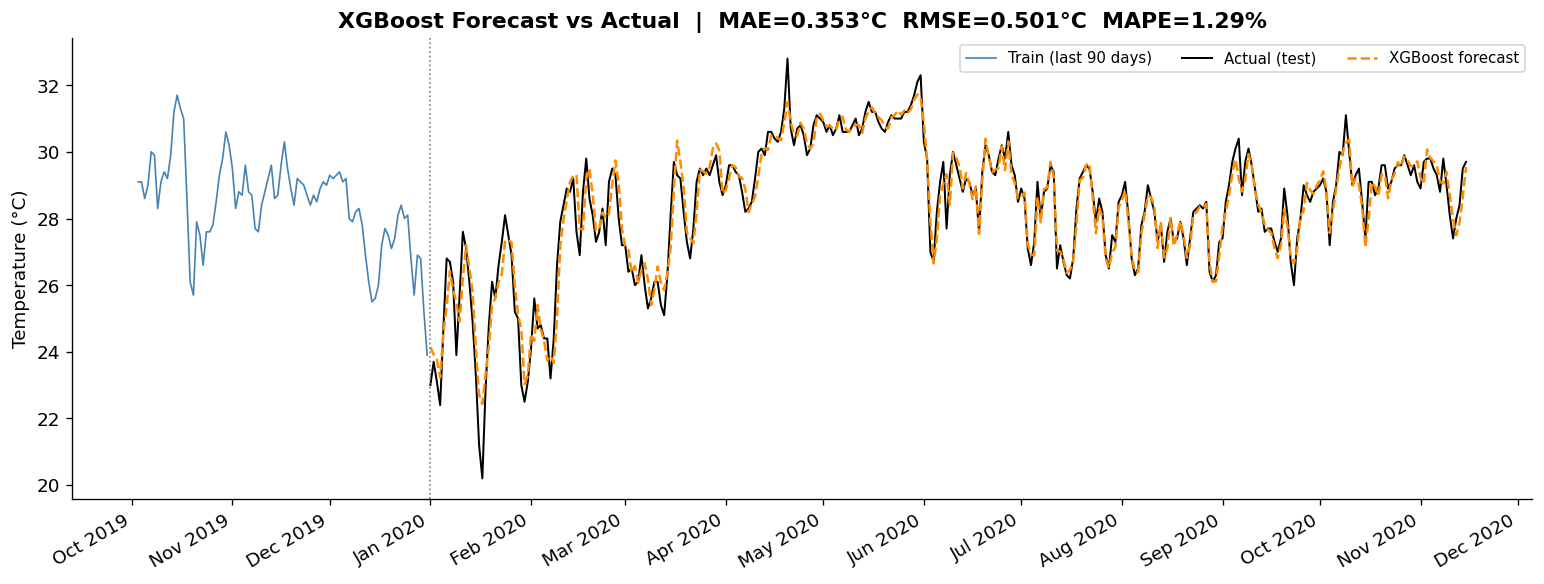

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train['datetime'].iloc[-90:], train[TARGET].iloc[-90:],
        color='steelblue', linewidth=1, label='Train (last 90 days)')
ax.plot(test['datetime'], y_test_xgb,
        color='black', linewidth=1.2, label='Actual (test)')
ax.plot(test['datetime'], y_pred_xgb,
        color='darkorange', linewidth=1.5, linestyle='--',
        label='XGBoost forecast')
ax.axvline(test['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
ax.set_ylabel('Temperature (°C)')
ax.set_title(
    f'XGBoost Forecast vs Actual  |  MAE={mae_xgb:.3f}°C  RMSE={rmse_xgb:.3f}°C  MAPE={mape_xgb:.2f}%',
    fontweight='bold'
)
ax.legend(fontsize=9, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_xgb_forecast.png', bbox_inches='tight')
plt.show()

## 4.20 Model Comparison

In [20]:
# --- Summary comparison table ---
from sklearn.metrics import r2_score

comparison = pd.DataFrame({
    'Model'         : ['SARIMA', 'SARIMAX', 'XGBoost'],
    'Type'          : ['Statistical', 'Statistical', 'Machine Learning'],
    'AIC'           : [round(sarima_fit.aic,  2), round(sarimax_fit.aic, 2), 'N/A'],
    'BIC'           : [round(sarima_fit.bic,  2), round(sarimax_fit.bic, 2), 'N/A'],
    'Train RMSE'    : [round(rmse_s_train, 4), round(rmse_sx_train, 4), round(rmse_xgb_train, 4)],
    'Test MAE'      : [round(mae_s,   4), round(mae_sx,  4), round(mae_xgb,  4)],
    'Test RMSE'     : [round(rmse_s,  4), round(rmse_sx, 4), round(rmse_xgb, 4)],
    'Test MAPE(%)'  : [round(mape_s,  4), round(mape_sx, 4), round(mape_xgb, 4)],
    'Test R²'       : [round(r2_s,    4), round(r2_sx,   4), round(r2_xgb,   4)],
    'RMSE ratio'    : [
        round(rmse_s/rmse_s_train,   2),
        round(rmse_sx/rmse_sx_train, 2),
        round(rmse_xgb/rmse_xgb_train, 2)
    ]
})

print('=== Model Comparison: SARIMA vs SARIMAX vs XGBoost ===')
print(comparison.to_string(index=False))

# Highlight best model per metric
print('\n=== Best Model per Metric ===')
for metric in ['Test MAE', 'Test RMSE', 'Test MAPE(%)', 'Test R²']:
    vals  = comparison[metric].values
    names = comparison['Model'].values
    if metric == 'Test R²':
        best_idx = int(np.argmax([float(v) for v in vals]))
        best_val = max([float(v) for v in vals])
    else:
        best_idx = int(np.argmin([float(v) for v in vals]))
        best_val = min([float(v) for v in vals])
    print(f'  {metric:15s}: {names[best_idx]} ({best_val})')


=== Model Comparison: SARIMA vs SARIMAX vs XGBoost ===
  Model             Type      AIC      BIC  Train RMSE  Test MAE  Test RMSE  Test MAPE(%)  Test R²  RMSE ratio
 SARIMA      Statistical  3470.46  3502.03      1.2212    0.6100     0.8131        2.2155   0.8362        0.67
SARIMAX      Statistical   789.87   842.49      0.9819    0.2310     0.3129        0.8316   0.9758        0.32
XGBoost Machine Learning      N/A      N/A      0.3533    0.3532     0.5012        1.2899   0.9378        1.42

=== Best Model per Metric ===
  Test MAE       : SARIMAX (0.231)
  Test RMSE      : SARIMAX (0.3129)
  Test MAPE(%)   : SARIMAX (0.8316)
  Test R²        : SARIMAX (0.9758)


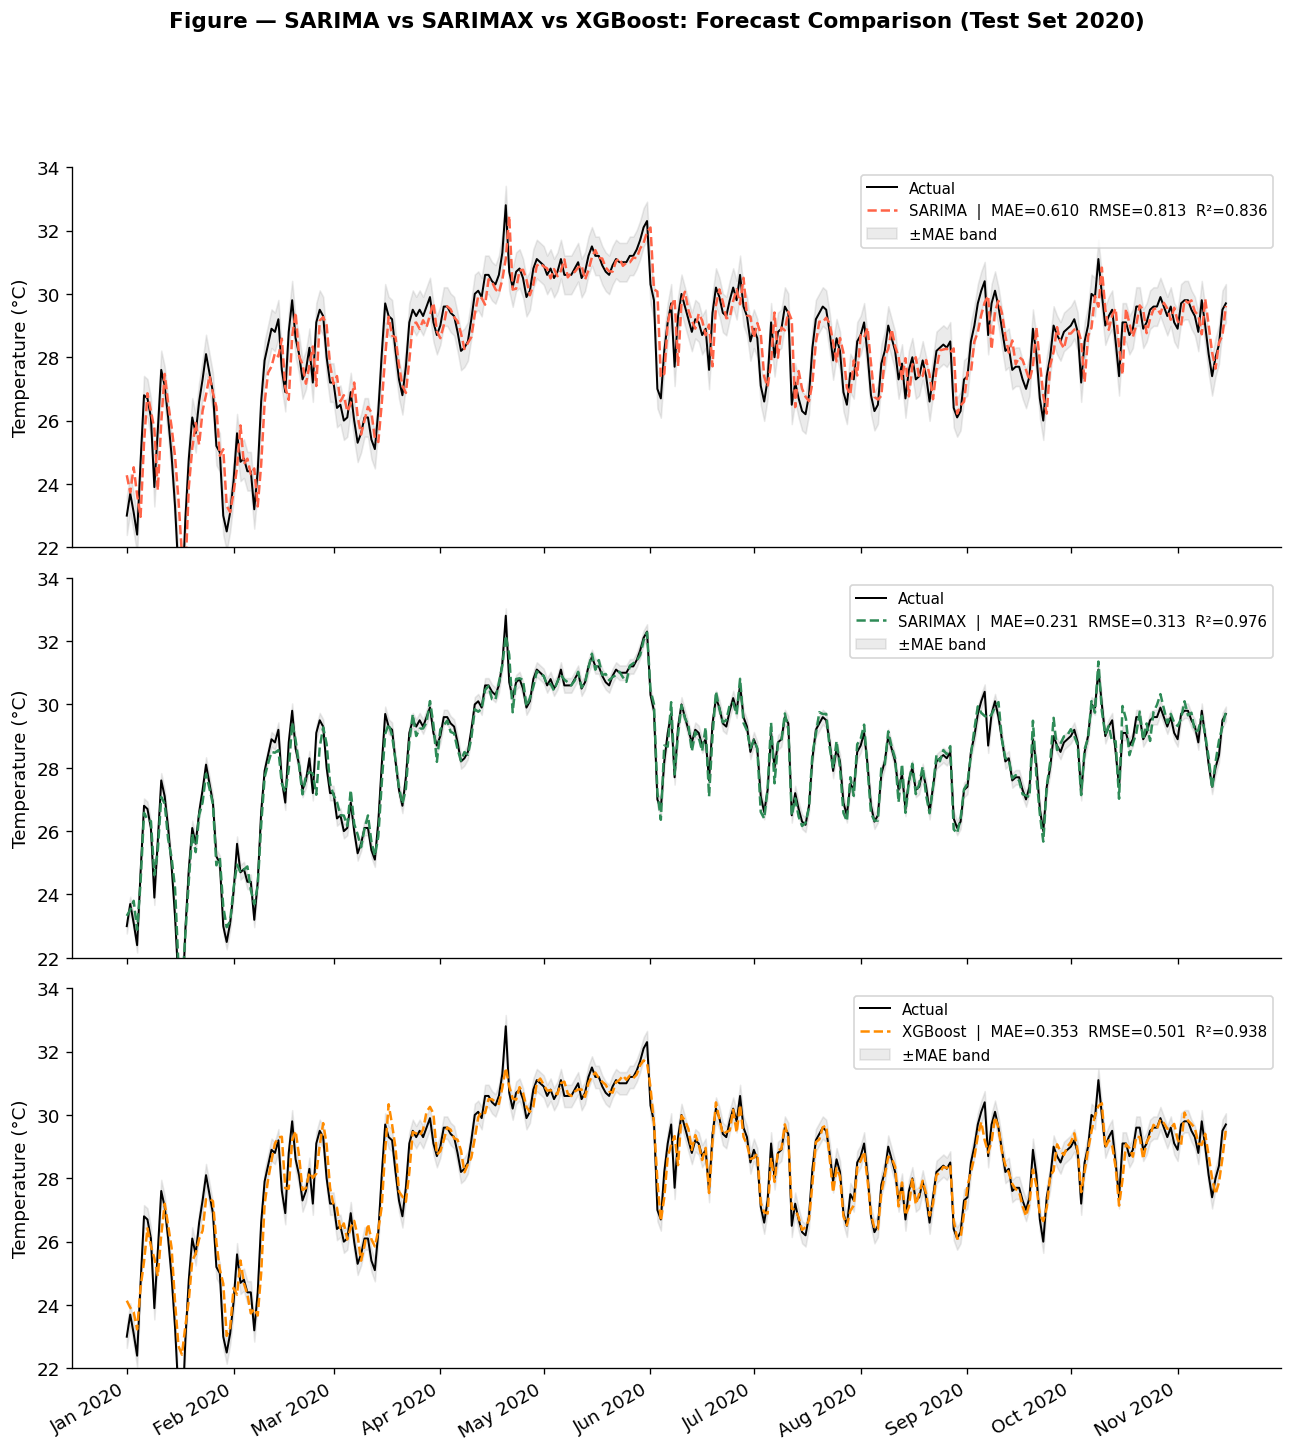

In [21]:
# --- 3-model forecast comparison plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True,
                          gridspec_kw={'hspace': 0.08})

model_info = [
    (y_pred_sarima,  'tomato',     'SARIMA',   mae_s,   rmse_s,   r2_s),
    (y_pred_sarimax, 'seagreen',   'SARIMAX',  mae_sx,  rmse_sx,  r2_sx),
    (y_pred_xgb,     'darkorange', 'XGBoost',  mae_xgb, rmse_xgb, r2_xgb),
]

for ax, (y_pred, color, label, mae, rmse, r2) in zip(axes, model_info):
    ax.plot(test['datetime'], y_test,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test['datetime'], y_pred, color=color,
            linewidth=1.5, linestyle='--',
            label=f'{label}  |  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
    ax.fill_between(test['datetime'],
                    y_test - mae, y_test + mae,
                    alpha=0.08, color='black', label='±MAE band')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(22, 34)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
fig.suptitle('Figure — SARIMA vs SARIMAX vs XGBoost: Forecast Comparison (Test Set 2020)',
             fontsize=13, fontweight='bold')
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()
